Loading data, training models, and calculating metric rankings...

Table V Saved Successfully: 'table_5_model_rankings.csv'
                 Model  Rank by Accuracy  Rank by Recall  Rank by F1  \
0  Logistic Regression                 2               2           4   
1        Random Forest                 3               3           2   
2              XGBoost                 1               1           1   
3                  SVM                 4               4           3   

   Rank by AUC  
0            4  
1            1  
2            2  
3            3  
Figure 5 Saved Successfully: 'figure_5_metric_sensitivity.pdf'


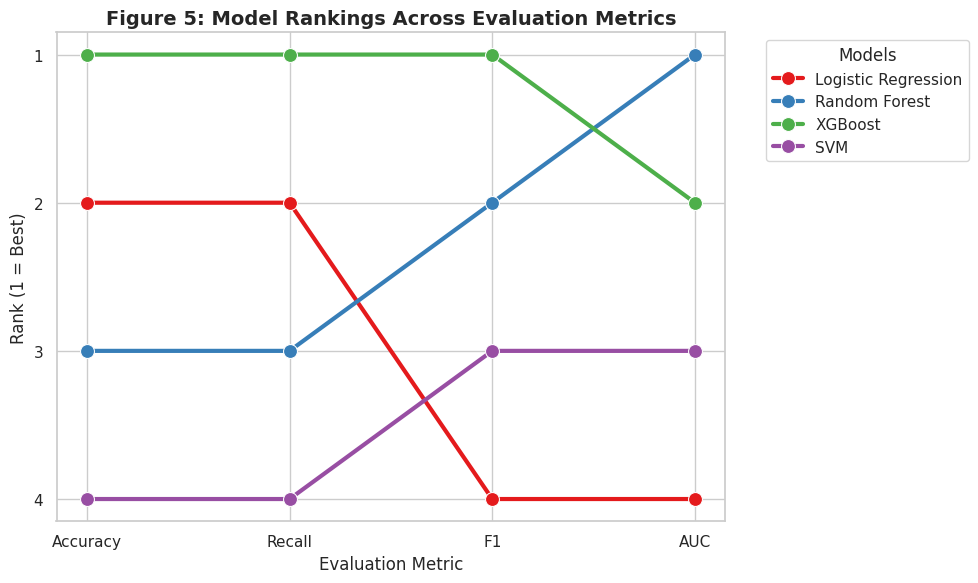

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# --- Configuration ---
DATA_PATH = '/kaggle/input/datasets/imranalishahh/marketing-and-product-performance-dataset/marketing_and_product_performance.csv'
TARGET_COLUMN = 'Subscription_Tier' 

print("Loading data, training models, and calculating metric rankings...")
try:
    df = pd.read_csv(DATA_PATH)
    
    # 1. Preprocessing (Full Pipeline)
    cols_to_drop = [col for col in df.columns if 'ID' in col.upper()]
    df = df.drop(columns=cols_to_drop, errors='ignore')
    
    y_raw = df[TARGET_COLUMN]
    X_raw = df.drop(TARGET_COLUMN, axis=1)
    
    le_y = LabelEncoder()
    y = le_y.fit_transform(y_raw)
    
    X = X_raw.copy()
    num_cols = X.select_dtypes(include=['float64', 'int64']).columns
    cat_cols = X.select_dtypes(include=['object']).columns
    
    imputer_num = SimpleImputer(strategy='median')
    X[num_cols] = imputer_num.fit_transform(X[num_cols])
    
    imputer_cat = SimpleImputer(strategy='most_frequent')
    X[cat_cols] = imputer_cat.fit_transform(X[cat_cols])
    
    for col in cat_cols:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
        
    scaler = StandardScaler()
    X[num_cols] = scaler.fit_transform(X[num_cols])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. Train Models
    models = {
        'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
        'XGBoost': XGBClassifier(random_state=42),
        'SVM': SVC(probability=True, random_state=42) # probability=True needed for AUC
    }
    
    raw_scores = []
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)
        
        raw_scores.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
            'F1': f1_score(y_test, y_pred, average='weighted', zero_division=0),
            'AUC': roc_auc_score(y_test, y_proba, multi_class='ovr')
        })
        
    scores_df = pd.DataFrame(raw_scores)
    
    # 3. Convert Scores to Rankings (1 is best)
    # We use rank(method='min', ascending=False) because higher score = better rank (rank 1)
    rankings_df = pd.DataFrame({'Model': scores_df['Model']})
    rankings_df['Rank by Accuracy'] = scores_df['Accuracy'].rank(method='min', ascending=False).astype(int)
    rankings_df['Rank by Recall'] = scores_df['Recall'].rank(method='min', ascending=False).astype(int)
    rankings_df['Rank by F1'] = scores_df['F1'].rank(method='min', ascending=False).astype(int)
    rankings_df['Rank by AUC'] = scores_df['AUC'].rank(method='min', ascending=False).astype(int)
    
    # --- Generate Table V ---
    rankings_df.to_csv('table_5_model_rankings.csv', index=False)
    print("\nTable V Saved Successfully: 'table_5_model_rankings.csv'")
    print(rankings_df)

    # --- Generate Figure 5 ---
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # Melt dataframe for line plotting (Bump Chart style)
    melted_ranks = rankings_df.melt(id_vars='Model', var_name='Metric', value_name='Rank')
    
    # Clean up metric names for the X-axis
    melted_ranks['Metric'] = melted_ranks['Metric'].str.replace('Rank by ', '')
    
    sns.lineplot(data=melted_ranks, x='Metric', y='Rank', hue='Model', 
                 marker='o', linewidth=3, markersize=10, palette='Set1')
    
    plt.title('Figure 5: Model Rankings Across Evaluation Metrics', fontsize=14, fontweight='bold')
    plt.xlabel('Evaluation Metric', fontsize=12)
    plt.ylabel('Rank (1 = Best)', fontsize=12)
    
    # Invert Y-axis so Rank 1 is at the top
    plt.gca().invert_yaxis()
    plt.yticks([1, 2, 3, 4]) 
    
    # Move legend outside the plot
    plt.legend(title='Models', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plt.savefig('figure_5_metric_sensitivity.pdf', format='pdf', bbox_inches='tight')
    print("Figure 5 Saved Successfully: 'figure_5_metric_sensitivity.pdf'")
    
    plt.show()

except FileNotFoundError:
    print(f"Error: Could not find the dataset at {DATA_PATH}.")